# Visualize UniDepthLSS

A random validation sample is selected on every run. Ground truth is blue, the raw thresholded prediction is red, roads are gray, and the ego vehicle is white.

In [ ]:
import sys
from pathlib import Path

import torch

DATA_ROOT = Path("Path/to/nuScenes")
CHECKPOINT = Path("Path/to/checkpoint.pth")
UNIDEPTH_ROOT = Path("path/to/unidepth").resolve()
sys.path.insert(0, str(UNIDEPTH_ROOT))

from dataset_nuscenes import NuScenesBEVDataset
from model import UniDepthLSS
from visualization import visualize_random_sample

IMAGE_SIZE = (448, 798)
BEV_SIZE = 128
BEV_RESOLUTION = 0.5
PREDICTION_THRESHOLD = 0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
dataset = NuScenesBEVDataset(
    dataroot=str(DATA_ROOT), version="v1.0-trainval", split="val",
    img_size=IMAGE_SIZE, bev_size=BEV_SIZE, bev_res=BEV_RESOLUTION, augment=False,
)
model = UniDepthLSS(
    img_height=IMAGE_SIZE[0], img_width=IMAGE_SIZE[1],
    num_classes=1, feature_channels=128,
).to(DEVICE)
checkpoint = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

/home/adeel/anaconda3/envs/VGGT/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/adeel/UniDepth/unidepth/utils/chamfer_distance.py:9: UserWarning: !! To run evaluation you need KNN. Please compile KNN: `cd unidepth/ops/knn with && bash compile.sh`.
  warnings.warn(
xFormers not available
xFormers not available


Cannot import NystromAttention, you can not run original UniDepth. UniDepthV2 is available.
Not loading pretrained weights for backbone


UniDepthLSS(
  (projector): _LiftSplatProjector(
    (backbone): UniDepthV2(
      (pixel_encoder): DinoVisionTransformer(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
          (norm): Identity()
        )
        (blocks): ModuleList(
          (0-23): 24 x NestedTensorBlock(
            (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (attn): MemEffAttention(
              (qkv): Linear(in_features=1024, out_features=3072, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=1024, out_features=1024, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): LayerScale()
            (drop_path1): Identity()
            (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=1024, out_features=4096, bias=True)
              (act)

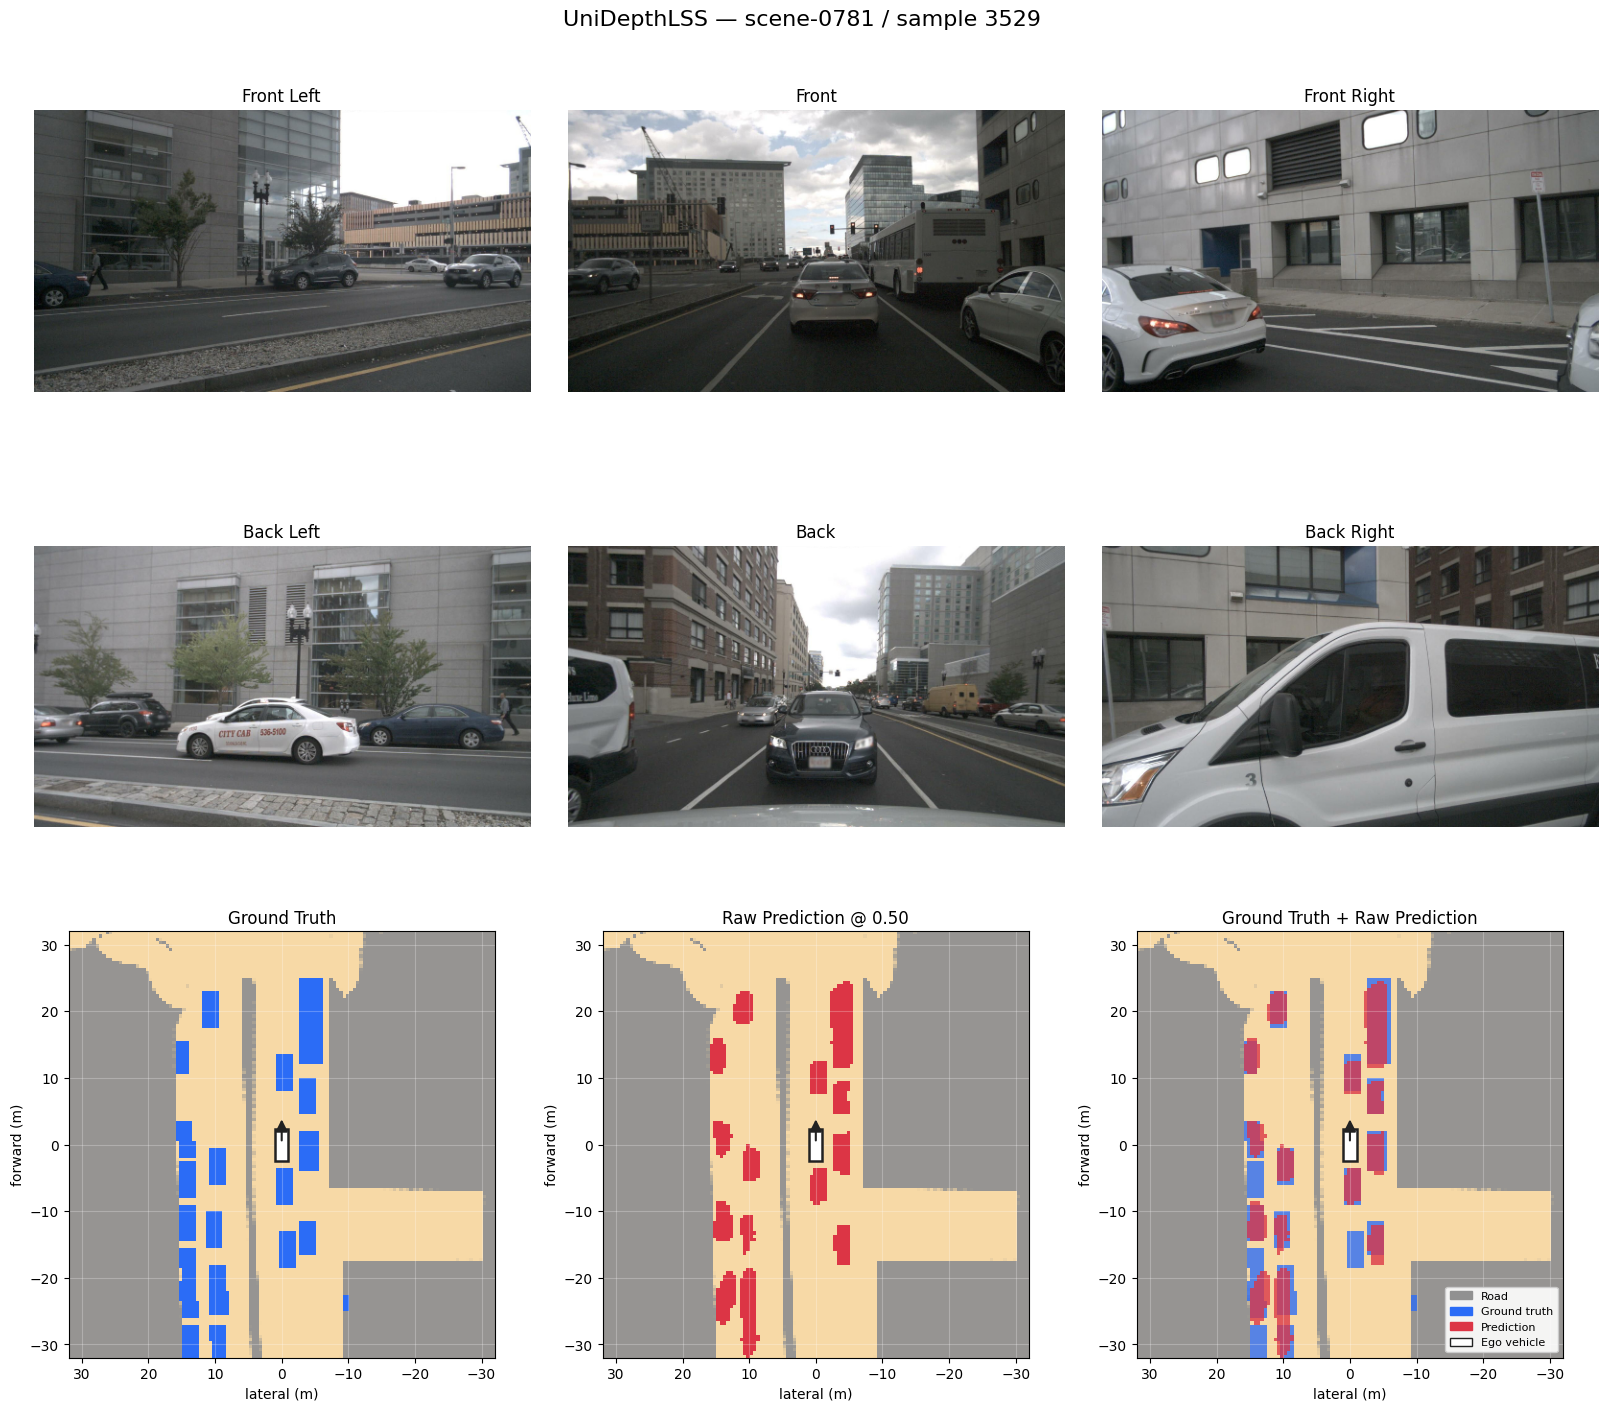

Visualized validation sample 3529


In [8]:
figure, sample_index = visualize_random_sample(
    dataset, model, DEVICE, DATA_ROOT,
    threshold=PREDICTION_THRESHOLD, bev_resolution=BEV_RESOLUTION,
)
print(f"Visualized validation sample {sample_index}")